#  Código usando Dask-Awkward

In [1]:
import uproot
import awkward as ak
import dask_awkward as dak
import dask
import numpy as np
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import mplhep as hep

# ==============================================================================
# FUNÇÃO DE TRUTH MATCHING PARA CANDIDATOS RECO
# ==============================================================================
def get_reco_truth_mask(df):
    # --- 1. Constantes PDG ---
    PDG_B0        = 511
    PDG_KSTAR     = 313
    PDG_KAON_plus = 321
    PDG_PION_neg  = -211
    PDG_MUON_plus = -13
    PDG_MUON_neg  = 13
    PDG_PHOTON    = 22

    # Pega os índices genéticos dos candidatos RECO (Shape: BToTrkTrkMuMu)
    mu1_idx  = df["BPHMuon_genPartIdx"][df["BToTrkTrkMuMu_l1_idx"]]
    mu2_idx  = df["BPHMuon_genPartIdx"][df["BToTrkTrkMuMu_l2_idx"]]
    trk1_idx = df["Track_genPartIdx"][df["BToTrkTrkMuMu_trk1_idx"]]
    trk2_idx = df["Track_genPartIdx"][df["BToTrkTrkMuMu_trk2_idx"]]

    pdg_id     = df["BPHGenPart_pdgId"]
    mother_idx = df["BPHGenPart_genPartIdxMother"]

    # Mascara índices inválidos (-1) para evitar IndexError.
    # O -1 vira 'None' e a operação propaga o 'None' de forma segura.
    mu1_idx_safe  = dak.mask(mu1_idx, mu1_idx >= 0)
    mu2_idx_safe  = dak.mask(mu2_idx, mu2_idx >= 0)
    trk1_idx_safe = dak.mask(trk1_idx, trk1_idx >= 0)
    trk2_idx_safe = dak.mask(trk2_idx, trk2_idx >= 0)

    # Verificação de Identidade (PDG ID)
    mu1_pdg  = pdg_id[mu1_idx_safe]
    mu2_pdg  = pdg_id[mu2_idx_safe]
    trk1_pdg = pdg_id[trk1_idx_safe]
    trk2_pdg = pdg_id[trk2_idx_safe]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    # Linhagem do Hadron (K, Pi -> K* -> B0)
    mom_trk1_idx = mother_idx[trk1_idx_safe]
    mom_trk2_idx = mother_idx[trk2_idx_safe]
    
    mom_trk1_idx_safe = dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)
    mom_trk2_idx_safe = dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)
    
    mom_trk1_pdg = pdg_id[mom_trk1_idx_safe]
    mom_trk2_pdg = pdg_id[mom_trk2_idx_safe]
    
    # K e Pi devem vir do mesmo objeto K*0
    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)
    
    # O K*0 deve vir de um B0
    gmom_trk1_idx = mother_idx[mom_trk1_idx_safe]
    gmom_trk2_idx = mother_idx[mom_trk2_idx_safe]
    
    gmom_trk1_idx_safe = dak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)
    gmom_trk2_idx_safe = dak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)
    
    gmom_trk1_pdg = pdg_id[gmom_trk1_idx_safe]
    gmom_trk2_pdg = pdg_id[gmom_trk2_idx_safe]
    
    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    # Linhagem dos Múons
    mom_mu1_idx = mother_idx[mu1_idx_safe]
    mom_mu2_idx = mother_idx[mu2_idx_safe]
    
    mom_mu1_idx_safe = dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)
    mom_mu2_idx_safe = dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)
    
    mom_mu1_pdg = pdg_id[mom_mu1_idx_safe]
    mom_mu2_pdg = pdg_id[mom_mu2_idx_safe]
    
    gmom_mu1_idx = mother_idx[mom_mu1_idx_safe]
    gmom_mu2_idx = mother_idx[mom_mu2_idx_safe]

    # Muon: Mãe é o B0 do hadron OU (Mãe é fóton e Avó é o B0 do hadron)
    mu1_from_same_b0 = (mom_mu1_idx == gmom_trk1_idx) | \
                       ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu1_idx == gmom_trk1_idx))

    mu2_from_same_b0 = (mom_mu2_idx == gmom_trk1_idx) | \
                       ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_idx == gmom_trk1_idx))

    # --- Máscara Final ---
    full_mask = flavor_match & match_kstar & match_kstar_to_b0 & \
                mu1_from_same_b0 & mu2_from_same_b0
    
    # Preenche tudo que virou 'None' com False
    return dak.fill_none(full_mask, False)

# ==============================================================================
# SCRIPT PRINCIPAL
# ==============================================================================
file_path = "/cms/store/user/tdeandra/BPH_NanoAOD_MC/BdtoKstar2Mu_KstartoKPi_TuneCP5_13p6TeV_pythia8-evtgen/BPH_Nano_MC_BdtoKstarMuMu_NoFilter_2022/260427_132612/0000/BPH_MC_NANO_1.root"

print("Abrindo arquivo e montando grafo lazy...")

# Carrega TODOS os branches exigidos
arrays = uproot.dask(
    {file_path: "Events"},
    expressions=[
        "BPHGenPart_pdgId", 
        "BPHGenPart_genPartIdxMother", 
        "BPHGenPart_mass",
        "BPHMuon_genPartIdx",
        "Track_genPartIdx",
        "BToTrkTrkMuMu_l1_idx", 
        "BToTrkTrkMuMu_l2_idx",
        "BToTrkTrkMuMu_trk1_idx", 
        "BToTrkTrkMuMu_trk2_idx",
        "BToTrkTrkMuMu_fit_mass_Kpi" # <-- Apenas esta variável será filtrada
    ],
    library="ak"
)

print(f"Número de partições: {arrays.npartitions}")

# 1. Cria a máscara (que terá o formato (shape) da coleção BToTrkTrkMuMu)
mask_lazy = get_reco_truth_mask(arrays)

# 2. Pega EXCLUSIVAMENTE a última variável para aplicar o filtro
raw_fit_mass_kpi = arrays["BToTrkTrkMuMu_fit_mass_Kpi"]

# 3. Aplica a máscara na variável
masked_fit_mass_kpi = raw_fit_mass_kpi[mask_lazy]

# 4. Descobre quais eventos possuem pelo menos 1 candidato válido
event_has_signal = dak.num(masked_fit_mass_kpi, axis=1) > 0

# 5. Filtra eventos vazios
final_fit_mass_kpi = masked_fit_mass_kpi[event_has_signal]

print("\nExecutando com barra de progresso...")
with ProgressBar():
    # Computa as coleções do Dask para a memória
    # Nota: dask.compute retorna uma tupla, então usamos a vírgula para desempacotar
    clean_fit_mass_kpi, = dask.compute(final_fit_mass_kpi)

print(f"\nTotal de eventos de SINAL retidos: {len(clean_fit_mass_kpi)}")

for i in range(min(5, len(clean_fit_mass_kpi))):
    print(f"\nEvento {i}:")
    print(f"  Fit Mass KPi: {clean_fit_mass_kpi[i].tolist()}")

Abrindo arquivo e montando grafo lazy...
Número de partições: 1

Executando com barra de progresso...
[########################################] | 100% Completed | 206.52 ms
[########################################] | 100% Completed | 1.44 ss

Total de eventos de SINAL retidos: 1810

Evento 0:
  Fit Mass KPi: [5.387378692626953]

Evento 1:
  Fit Mass KPi: [5.2874674797058105]

Evento 2:
  Fit Mass KPi: [5.255512237548828]

Evento 3:
  Fit Mass KPi: [5.2592878341674805]

Evento 4:
  Fit Mass KPi: [5.266177177429199]


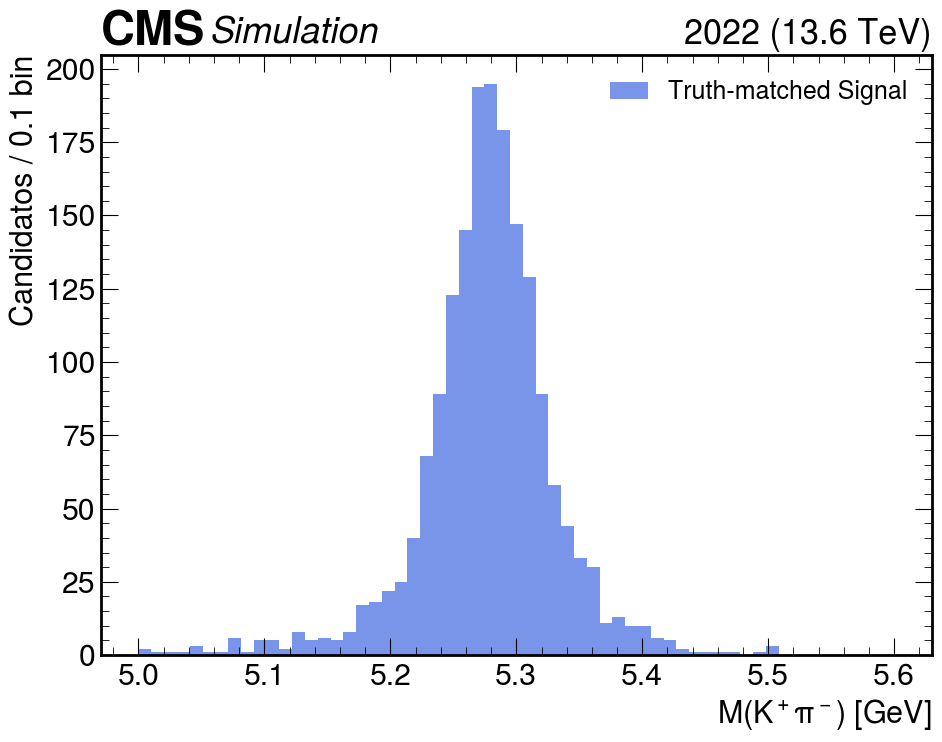

In [2]:
mass_array = np.asarray(ak.flatten(clean_fit_mass_kpi))
hep.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

bins = np.linspace(5.0, 5.6, 60)
counts, edges = np.histogram(mass_array, bins=bins)

hep.histplot(
    counts, 
    bins=edges, 
    ax=ax, 
    histtype='fill', 
    color='royalblue', 
    alpha=0.7, 
    edgecolor='black', 
    label='Truth-matched Signal'
)

hep.cms.label(loc=0, ax=ax, data=False, lumi=None, year=2022, com = 13.6)
ax.set_xlabel(r'$M(K^+ \pi^-)$ [GeV]', fontsize=22)
ax.set_ylabel('Candidatos / 0.1 bin', fontsize=22)
ax.legend(loc='upper right', fontsize=18)

plt.tight_layout()
plt.show()

# Código usando Loop Python + Numba

In [3]:
import uproot
import awkward as ak
import numba as nb
import numpy as np

# ==============================================================================
# FUNÇÃO NUMBA PARA TRUTH MATCHING RECO
# CANAL NÃO-RESSONANTE:
#
# B0 -> K* mu+ mu-
# K* -> K+ pi-
#
# aceita:
#   B0 -> mu mu
#   B0 -> gamma -> mu
# ==============================================================================

@nb.njit
def build_reco_truth_mask_nonresonant(
    pdgs_events,
    moms_events,
    muon_gen_idx_events,
    track_gen_idx_events,
    l1_idx_events,
    l2_idx_events,
    trk1_idx_events,
    trk2_idx_events
):

    # ==========================================================================
    # PDGs
    # ==========================================================================

    PDG_B0        =  511
    PDG_KSTAR     =  313
    PDG_KAON      =  321
    PDG_PION      = -211

    PDG_MU_PLUS   = -13
    PDG_MU_MINUS  =  13

    PDG_PHOTON    =  22

    n_events = len(pdgs_events)

    reco_masks = nb.typed.List()

    # ==========================================================================
    # LOOP NOS EVENTOS
    # ==========================================================================

    for i in range(n_events):

        pdgs = pdgs_events[i]
        moms = moms_events[i]

        mu_gen  = muon_gen_idx_events[i]
        trk_gen = track_gen_idx_events[i]

        l1_idx   = l1_idx_events[i]
        l2_idx   = l2_idx_events[i]

        trk1_idx = trk1_idx_events[i]
        trk2_idx = trk2_idx_events[i]

        n_cands = len(l1_idx)

        cand_mask = np.zeros(n_cands, dtype=np.bool_)

        # ======================================================================
        # LOOP NOS CANDIDATOS RECO
        # ======================================================================

        for j in range(n_cands):

            # ------------------------------------------------------------------
            # índices RECO
            # ------------------------------------------------------------------

            reco_l1   = l1_idx[j]
            reco_l2   = l2_idx[j]

            reco_trk1 = trk1_idx[j]
            reco_trk2 = trk2_idx[j]

            # proteção
            if (
                reco_l1   < 0 or
                reco_l2   < 0 or
                reco_trk1 < 0 or
                reco_trk2 < 0
            ):
                continue

            if (
                reco_l1   >= len(mu_gen) or
                reco_l2   >= len(mu_gen) or
                reco_trk1 >= len(trk_gen) or
                reco_trk2 >= len(trk_gen)
            ):
                continue

            # ------------------------------------------------------------------
            # índices GEN
            # ------------------------------------------------------------------

            mu1_gen_idx  = mu_gen[reco_l1]
            mu2_gen_idx  = mu_gen[reco_l2]

            trk1_gen_idx = trk_gen[reco_trk1]
            trk2_gen_idx = trk_gen[reco_trk2]

            if (
                mu1_gen_idx  < 0 or
                mu2_gen_idx  < 0 or
                trk1_gen_idx < 0 or
                trk2_gen_idx < 0
            ):
                continue

            # ==================================================================
            # 1. MATCH DE FLAVOR
            # ==================================================================

            mu1_pdg  = pdgs[mu1_gen_idx]
            mu2_pdg  = pdgs[mu2_gen_idx]

            trk1_pdg = pdgs[trk1_gen_idx]
            trk2_pdg = pdgs[trk2_gen_idx]

            flavor_match = (
                (trk1_pdg == PDG_KAON) and
                (trk2_pdg == PDG_PION) and
                (mu1_pdg  == PDG_MU_PLUS) and
                (mu2_pdg  == PDG_MU_MINUS)
            )

            if not flavor_match:
                continue

            # ==================================================================
            # 2. K* -> K pi
            # ==================================================================

            mom_trk1_idx = moms[trk1_gen_idx]
            mom_trk2_idx = moms[trk2_gen_idx]

            if mom_trk1_idx < 0 or mom_trk2_idx < 0:
                continue

            mom_trk1_pdg = pdgs[mom_trk1_idx]
            mom_trk2_pdg = pdgs[mom_trk2_idx]

            match_kstar = (
                (mom_trk1_idx == mom_trk2_idx) and
                (mom_trk1_pdg == PDG_KSTAR) and
                (mom_trk2_pdg == PDG_KSTAR)
            )

            if not match_kstar:
                continue

            kstar_idx = mom_trk1_idx

            # ==================================================================
            # 3. K* -> B0
            # ==================================================================

            b0_idx = moms[kstar_idx]

            if b0_idx < 0:
                continue

            if pdgs[b0_idx] != PDG_B0:
                continue

            # ==================================================================
            # 4. LINHAGEM DOS MÚONS
            # ==================================================================

            mu1_mom_idx = moms[mu1_gen_idx]
            mu2_mom_idx = moms[mu2_gen_idx]

            if mu1_mom_idx < 0 or mu2_mom_idx < 0:
                continue

            mu1_mom_pdg = pdgs[mu1_mom_idx]
            mu2_mom_pdg = pdgs[mu2_mom_idx]

            # ------------------------------------------------------------------
            # mu+:
            #
            # B0 -> mu+
            # OU
            # B0 -> gamma -> mu+
            # ------------------------------------------------------------------

            mu1_match = False

            # direto do B0
            if mu1_mom_idx == b0_idx:
                mu1_match = True

            # via fóton
            elif mu1_mom_pdg == PDG_PHOTON:

                gamma1_idx = mu1_mom_idx

                gamma1_mom_idx = moms[gamma1_idx]

                if gamma1_mom_idx == b0_idx:
                    mu1_match = True

            # ------------------------------------------------------------------
            # mu-
            # ------------------------------------------------------------------

            mu2_match = False

            if mu2_mom_idx == b0_idx:
                mu2_match = True

            elif mu2_mom_pdg == PDG_PHOTON:

                gamma2_idx = mu2_mom_idx

                gamma2_mom_idx = moms[gamma2_idx]

                if gamma2_mom_idx == b0_idx:
                    mu2_match = True

            # ==================================================================
            # 5. VEREDITO FINAL
            # ==================================================================

            if mu1_match and mu2_match:
                cand_mask[j] = True

        reco_masks.append(cand_mask)

    return reco_masks


# ==============================================================================
# SCRIPT PRINCIPAL
# ==============================================================================

file_path = "/cms/store/user/tdeandra/BPH_NanoAOD_MC/BdtoKstar2Mu_KstartoKPi_TuneCP5_13p6TeV_pythia8-evtgen/BPH_Nano_MC_BdtoKstarMuMu_NoFilter_2022/260427_132612/0000/BPH_MC_NANO_1.root"

print("Abrindo arquivo...")

file = uproot.open(file_path)
tree = file["Events"]

# ==============================================================================
# CARREGA ARRAYS
# ==============================================================================

print("Carregando arrays...")

pdgs = tree["BPHGenPart_pdgId"].array()
moms = tree["BPHGenPart_genPartIdxMother"].array()

muon_gen_idx = tree["BPHMuon_genPartIdx"].array()
track_gen_idx = tree["Track_genPartIdx"].array()

l1_idx = tree["BToTrkTrkMuMu_l1_idx"].array()
l2_idx = tree["BToTrkTrkMuMu_l2_idx"].array()

trk1_idx = tree["BToTrkTrkMuMu_trk1_idx"].array()
trk2_idx = tree["BToTrkTrkMuMu_trk2_idx"].array()

fit_mass_kpi = tree["BToTrkTrkMuMu_fit_mass_Kpi"].array()

# ==============================================================================
# EXECUTA TRUTH MATCH
# ==============================================================================

print("Executando truth matching com Numba...")

reco_mask_numba = build_reco_truth_mask_nonresonant(
    pdgs,
    moms,
    muon_gen_idx,
    track_gen_idx,
    l1_idx,
    l2_idx,
    trk1_idx,
    trk2_idx
)

reco_mask = ak.Array(list(reco_mask_numba))

# ==============================================================================
# APLICA MÁSCARA
# ==============================================================================

fit_mass_matched = fit_mass_kpi[reco_mask]

event_has_signal = ak.num(fit_mass_matched, axis=1) > 0

fit_mass_final = fit_mass_matched[event_has_signal]

print(f"\nTotal de eventos de sinal retidos: {len(fit_mass_final)}")

# ==============================================================================
# DEBUG
# ==============================================================================

for i in range(min(5, len(fit_mass_final))):

    print(f"\nEvento {i}")
    print("fit_mass_Kpi =", fit_mass_final[i].tolist())

# ==============================================================================
# ARRAY FINAL ACHATADO
# ==============================================================================

mass_array = ak.to_numpy(ak.flatten(fit_mass_final))

print("\nNúmero total de candidatos matched:", len(mass_array))

Abrindo arquivo...
Carregando arrays...
Executando truth matching com Numba...

Total de eventos de sinal retidos: 1810

Evento 0
fit_mass_Kpi = [5.387378692626953]

Evento 1
fit_mass_Kpi = [5.2874674797058105]

Evento 2
fit_mass_Kpi = [5.255512237548828]

Evento 3
fit_mass_Kpi = [5.2592878341674805]

Evento 4
fit_mass_Kpi = [5.266177177429199]

Número total de candidatos matched: 1810


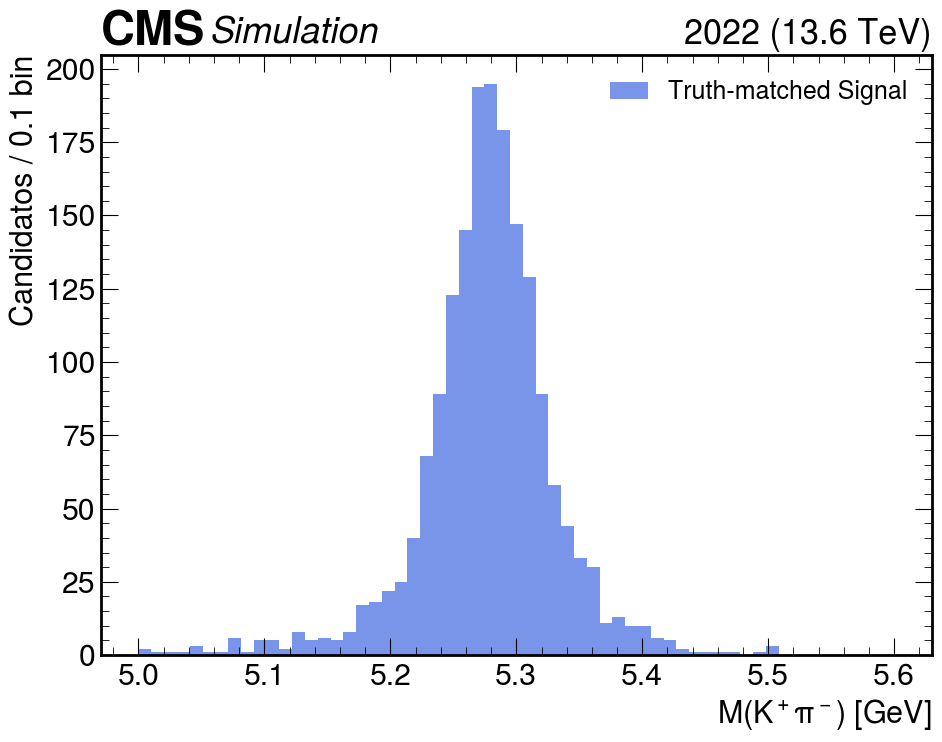

In [4]:
hep.style.use(hep.style.CMS)
fig, ax = plt.subplots(figsize=(10, 8))

bins = np.linspace(5.0, 5.6, 60)
counts, edges = np.histogram(mass_array, bins=bins)

hep.histplot(
    counts, 
    bins=edges, 
    ax=ax, 
    histtype='fill', 
    color='royalblue', 
    alpha=0.7, 
    edgecolor='black', 
    label='Truth-matched Signal'
)

hep.cms.label(loc=0, ax=ax, data=False, lumi=None, year=2022, com = 13.6)
ax.set_xlabel(r'$M(K^+ \pi^-)$ [GeV]', fontsize=22)
ax.set_ylabel('Candidatos / 0.1 bin', fontsize=22)
ax.legend(loc='upper right', fontsize=18)

plt.tight_layout()
plt.show()